## Step 0 — Setup & Configuration

Download the dataset from Kaggle and extract it locally (or mount it in Colab/Kaggle Notebooks). Set `DATASET_DIR` below to the extracted root folder.


In [1]:
import os, random, hashlib, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Kaggle Notebooks input path (confirmed via os.walk against /kaggle/input)
DATASET_DIR = Path(
    "/kaggle/input/datasets/shahriar26s/banana-ripeness-classification-dataset/"
    "Banana Ripeness Classification Dataset"
)

IMG_SIZE = (224, 224)   # matches standard ImageNet-pretrained input size
BATCH_SIZE = 32
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

In [2]:
# Raw listing — DO NOT assume folder names. Read this output.
assert DATASET_DIR.exists(), f"DATASET_DIR does not exist: {DATASET_DIR}. Fix the path above."

print("Contents of DATASET_DIR:")
for p in sorted(DATASET_DIR.rglob("*")):
    if p.is_dir():
        n_files = sum(1 for f in p.glob("*") if f.suffix.lower() in VALID_EXTS)
        if n_files > 0:
            print(f"  {p.relative_to(DATASET_DIR)}  ->  {n_files} image files")

Contents of DATASET_DIR:
  test/overripe  ->  113 image files
  test/ripe  ->  154 image files
  test/rotten  ->  185 image files
  test/unripe  ->  110 image files
  train/overripe  ->  2349 image files
  train/ripe  ->  3522 image files
  train/rotten  ->  4020 image files
  train/unripe  ->  1902 image files
  valid/overripe  ->  229 image files
  valid/ripe  ->  339 image files
  valid/rotten  ->  388 image files
  valid/unripe  ->  167 image files


**This dataset ships with a pre-made `train/valid/test` split, each containing `unripe/ripe/overripe/rotten` subfolders.**

We are deliberately **not** using that split as-is. Kaggle dataset uploaders routinely build train/test splits with a plain random shuffle over the raw files, with no duplicate/near-duplicate checking — if this one did that, near-duplicate or burst-shot images could already be split across their train and test folders, which would make their split (and any accuracy computed on their "test" folder) unreliable before we even start.

Instead: pool every image from all three official folders by class name (`unripe` / `ripe`, exact folder-name match, so `overripe` can't accidentally match a substring search), then run our own leak-safe, duplicate-grouped split from scratch in Step 2.

In [3]:
def collect_files(dataset_dir):
    records = []
    for p in dataset_dir.rglob("*"):
        if p.is_dir() and p.name in ("unripe", "ripe"):
            for f in p.glob("*"):
                if f.suffix.lower() in VALID_EXTS:
                    records.append({"path": str(f), "label": p.name, "official_split": p.parent.name})
    return pd.DataFrame(records)

df = collect_files(DATASET_DIR)
print(f"Total pooled images (unripe + ripe, all official splits combined): {len(df)}")
print()
print("By official split x class (for reference only — we are not using this split):")
print(df.groupby(["official_split", "label"]).size())


Total pooled images (unripe + ripe, all official splits combined): 6194

By official split x class (for reference only — we are not using this split):
official_split  label 
test            ripe       154
                unripe     110
train           ripe      3522
                unripe    1902
valid           ripe       339
                unripe     167
dtype: int64


## Step 1 — Audit the Data

Before any modeling: count images per class, check for corrupt files, check image dimensions, and flag near-duplicates. Ripeness datasets are frequently built from burst photography or short video frames of the same fruit — if a near-duplicate ends up in both train and test, your test accuracy is fiction.

In [4]:
from PIL import Image

# df was already pooled in Step 0 from the unripe/ripe folders across all three
# official splits. This cell just profiles it.
print(f"Total images collected: {len(df)}")
print(df["label"].value_counts())
print()
imbalance_ratio = df["label"].value_counts(normalize=True)
print("Class balance (fraction):")
print(imbalance_ratio)
if imbalance_ratio.max() / imbalance_ratio.min() > 1.5:
    print("\n>>> IMBALANCED. You will need class_weight in training below. <<<")

Total images collected: 6194
label
ripe      4015
unripe    2179
Name: count, dtype: int64

Class balance (fraction):
label
ripe      0.648208
unripe    0.351792
Name: proportion, dtype: float64

>>> IMBALANCED. You will need class_weight in training below. <<<


In [5]:
# Corrupt-file check + dimension audit (also catches accidental non-banana junk files)
def audit_image(path):
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            return im.size, im.mode
    except Exception as e:
        return None, str(e)

sizes, corrupt = [], []
for p in df["path"]:
    size, mode = audit_image(p)
    if size is None:
        corrupt.append((p, mode))
    else:
        sizes.append(size)

print(f"Corrupt/unreadable files: {len(corrupt)}")
for p, err in corrupt[:10]:
    print(" ", p, "->", err)

sizes_arr = np.array(sizes)
print(f"\nImage width  range: {sizes_arr[:,0].min()}–{sizes_arr[:,0].max()}, mean {sizes_arr[:,0].mean():.0f}")
print(f"Image height range: {sizes_arr[:,1].min()}–{sizes_arr[:,1].max()}, mean {sizes_arr[:,1].mean():.0f}")

# Drop corrupt files from df before proceeding
corrupt_paths = {p for p, _ in corrupt}
df = df[~df["path"].isin(corrupt_paths)].reset_index(drop=True)
print(f"\nUsable images after dropping corrupt files: {len(df)}")

Corrupt/unreadable files: 0

Image width  range: 416–416, mean 416
Image height range: 416–416, mean 416

Usable images after dropping corrupt files: 6194


In [6]:
# Near-duplicate detection via perceptual hash — this is what protects your split from leakage.
# pip install imagehash if not already available.
try:
    import imagehash
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "imagehash", "--break-system-packages", "-q"])
    import imagehash

def phash(path):
    try:
        with Image.open(path) as im:
            return str(imagehash.phash(im))
    except Exception:
        return None

df["phash"] = df["path"].apply(phash)
dup_groups = df.groupby("phash").filter(lambda g: len(g) > 1)
n_dup_groups = df.groupby("phash")["path"].nunique().gt(1).sum() if False else dup_groups["phash"].nunique()
print(f"Images sharing an identical/near-identical perceptual hash with >=1 other image: {len(dup_groups)}")
print(f"Number of duplicate groups: {dup_groups['phash'].nunique()}")

# group_id: use the phash as the leakage-prevention group key.
# Images that don't share a hash with anyone just form a group of size 1 (themselves).
df["group_id"] = df["phash"]
print(f"\nUnique groups overall: {df['group_id'].nunique()} (vs {len(df)} total images)")
if df['group_id'].nunique() < len(df) * 0.95:
    print(">>> Meaningful duplication detected. Group-based splitting below is NOT optional. <<<")

Images sharing an identical/near-identical perceptual hash with >=1 other image: 569
Number of duplicate groups: 223

Unique groups overall: 5848 (vs 6194 total images)
>>> Meaningful duplication detected. Group-based splitting below is NOT optional. <<<


## Step 2 — Group-Stratified Train/Val/Test Split

Standard `train_test_split` on individual images would let near-duplicate images (same banana, same photo, or a burst-shot sibling) land on both sides of the split, inflating your test accuracy. We split by `group_id` instead, so every image in a duplicate group stays entirely in one split.

Split: 70% train / 15% val / 15% test.

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def group_split(df, group_col, test_size, seed):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(gss.split(df, groups=df[group_col]))
    return df.iloc[idx_a].reset_index(drop=True), df.iloc[idx_b].reset_index(drop=True)

train_df, temp_df = group_split(df, "group_id", test_size=0.30, seed=SEED)
val_df, test_df = group_split(temp_df, "group_id", test_size=0.50, seed=SEED)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(d):5d} images  |  {dict(d['label'].value_counts())}")

# Sanity check: confirm zero group overlap between splits
train_groups, val_groups, test_groups = set(train_df.group_id), set(val_df.group_id), set(test_df.group_id)
assert not (train_groups & val_groups), "LEAKAGE: train/val share groups"
assert not (train_groups & test_groups), "LEAKAGE: train/test share groups"
assert not (val_groups & test_groups), "LEAKAGE: val/test share groups"
print("\nNo group overlap between splits — confirmed.")

train:  4321 images  |  {'ripe': np.int64(2807), 'unripe': np.int64(1514)}
val  :   937 images  |  {'ripe': np.int64(587), 'unripe': np.int64(350)}
test :   936 images  |  {'ripe': np.int64(621), 'unripe': np.int64(315)}

No group overlap between splits — confirmed.


## Step 3 — tf.data Pipeline

Augmentation choices matter here: aggressive hue/saturation jitter would corrupt the actual ripeness signal (color *is* the label), so we deliberately keep color augmentation light and lean on geometric augmentation (flips, rotation, zoom, translation) instead.

In [9]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
label_to_int = {"unripe": 0, "ripe": 1}

DISPLAY_LABEL = {"unripe": "Green", "ripe": "Yellow"}
DISPLAY_NAMES = [DISPLAY_LABEL["unripe"], DISPLAY_LABEL["ripe"]]  # index-ordered: 0, 1

def load_and_preprocess(path, label, training):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=0.08)   # light — avoid destroying color signal
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def make_dataset(d, training):
    paths = d["path"].values
    labels = d["label"].map(label_to_int).values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(d), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l, training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)
test_ds  = make_dataset(test_df,  training=False)

I0000 00:00:1785504492.948389      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785504492.951173      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Step 4 — Model: MobileNetV2 Transfer Learning

MobileNetV2 pretrained on ImageNet, frozen base + custom head, with a fine-tuning phase afterward. MobileNetV2 is the right size call here — this is a two-class, visually simple problem; a heavier backbone (ResNet50/EfficientNetB4) would be overkill and slower to iterate on, and you'd need to justify that cost too.

In [10]:
from tensorflow.keras import layers, models

def build_model(base_trainable=False):
    base = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
    )
    base.trainable = base_trainable

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model, base

model, base = build_model(base_trainable=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 5 — Training

Phase 1: frozen base, train the head only. Phase 2: unfreeze the top layers of MobileNetV2 and fine-tune at a low learning rate. `class_weight` is applied if Step 1 flagged imbalance — check that output before assuming you don't need it.

In [11]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
y_train_int = train_df["label"].map(label_to_int).values
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_int)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("class_weight:", class_weight)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint("best_model_phase1.keras", monitor="val_auc", mode="max", save_best_only=True),
]

history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=20, class_weight=class_weight, callbacks=callbacks,
)

class_weight: {0: 1.427014531043593, 1: 0.769682935518347}
Epoch 1/20


2026-07-31 13:28:31.892082: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 13:28:32.029045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1785504514.576828     155 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


135/136 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9176 - auc: 0.9635 - loss: 0.1857

2026-07-31 13:28:47.382874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 13:28:47.517164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9180 - auc: 0.9637 - loss: 0.1849

2026-07-31 13:29:04.182266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 13:29:04.324443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 13:29:04.461160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 239ms/step - accuracy: 0.9657 - auc: 0.9962 - loss: 0.0830 - val_accuracy: 0.9979 - val_auc: 1.0000 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9914 - auc: 0.9994 - loss: 0.0259 - val_accuracy: 0.9968 - val_auc: 1.0000 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9949 - auc: 0.9999 - loss: 0.0142 - val_accuracy: 0.9957 - val_auc: 1.0000 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9963 - auc: 0.9999 - loss: 0.0111 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9961 - auc: 0.9999 - loss: 0.0123 - val_accuracy: 0.9968 - val_auc: 1.0000 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9965 - auc: 1.000

In [12]:
# Phase 2: fine-tune the top of the base model at a low LR
base.trainable = True
FINE_TUNE_AT = len(base.layers) - 30   # unfreeze roughly the last 30 layers
for layer in base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model_final.keras", monitor="val_auc", mode="max", save_best_only=True),
]

history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, class_weight=class_weight, callbacks=callbacks_ft,
)

Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 162ms/step - accuracy: 0.9630 - auc: 0.9926 - loss: 0.1628 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0029
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9944 - auc: 0.9998 - loss: 0.0186 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0021
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9947 - auc: 0.9995 - loss: 0.0182 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0012
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9958 - auc: 0.9999 - loss: 0.0116 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 4.7814e-04
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9947 - auc: 0.9995 - loss: 0.0188 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 2.6440e-04
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9956 - auc: 0.9997 - loss: 0.0113 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 2.2243e-04


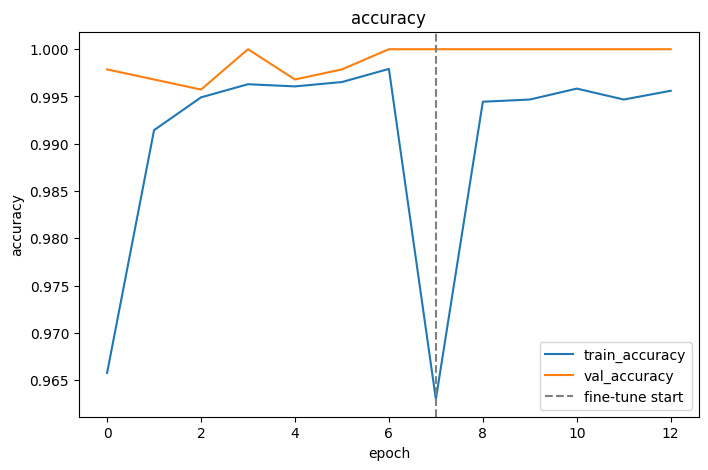

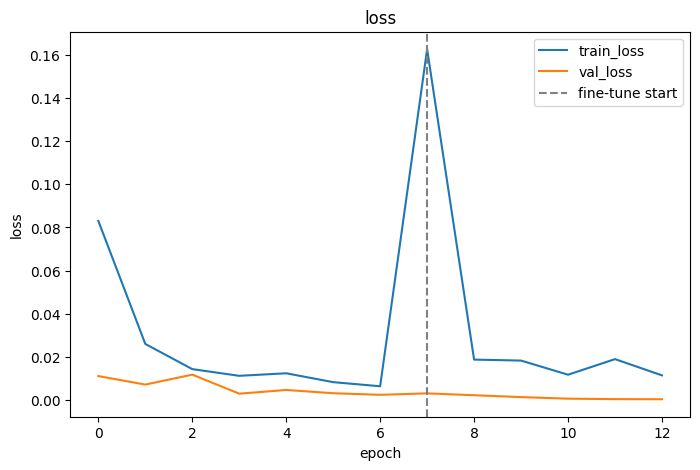

In [20]:
def plot_history(h1, h2, key):
    vals = h1.history[key] + h2.history[key]
    val_vals = h1.history[f"val_{key}"] + h2.history[f"val_{key}"]

    plt.figure(figsize=(8, 5))
    plt.plot(vals, label=f"train_{key}")
    plt.plot(val_vals, label=f"val_{key}")
    plt.axvline(len(h1.history[key]), color="gray", linestyle="--", label="fine-tune start")
    plt.xlabel("epoch")
    plt.ylabel(key)
    plt.legend()
    plt.title(key)

    plt.savefig(f"{key}_training_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
plot_history(history1, history2, "accuracy")
plot_history(history1, history2, "loss")

## Step 6 — Test Set Evaluation

Report accuracy, precision/recall/F1, confusion matrix, and AUC on the untouched test split — and compare directly against the Step 3 baseline number.

28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

2026-07-31 13:30:59.230270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-31 13:30:59.366631: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 401ms/step
Baseline accuracy : 0.6571
CNN accuracy      : 0.9989
CNN AUC           : 1.0000

              precision    recall  f1-score   support

       Green       0.38      0.03      0.06       315
      Yellow       0.66      0.97      0.79       621

    accuracy                           0.66       936
   macro avg       0.52      0.50      0.42       936
weighted avg       0.57      0.66      0.54       936



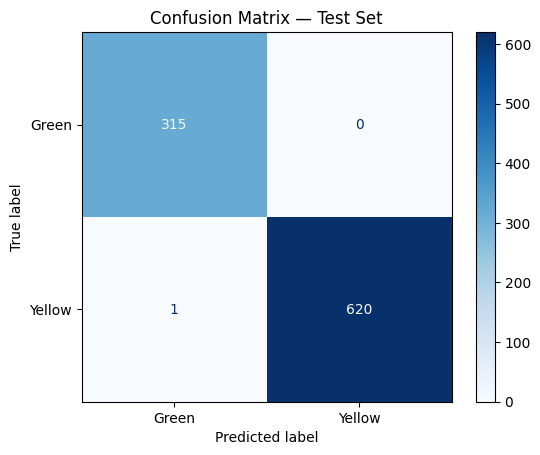

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

y_true = test_df["label"].map(label_to_int).values
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cnn_acc = accuracy_score(y_true, y_pred)
cnn_auc = roc_auc_score(y_true, y_prob)

print(f"Baseline accuracy : {baseline_acc:.4f}")
print(f"CNN accuracy      : {cnn_acc:.4f}")
print(f"CNN AUC           : {cnn_auc:.4f}")
print()
print(classification_report(y_test, baseline_preds, target_names=DISPLAY_NAMES))


cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=DISPLAY_NAMES).plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()

if cnn_acc <= baseline_acc + 0.02:
    print(">>> CNN barely beats the color-histogram baseline. That's a finding, not a failure — "
          "report it honestly rather than burying it. <<<")

## Step 8 — Error Analysis

Look at what's actually being misclassified. For this task, expect most errors to cluster around transitional bananas (green with yellow blush, or vice versa) — genuinely ambiguous ripeness, not model failure.

Misclassified: 1 / 936


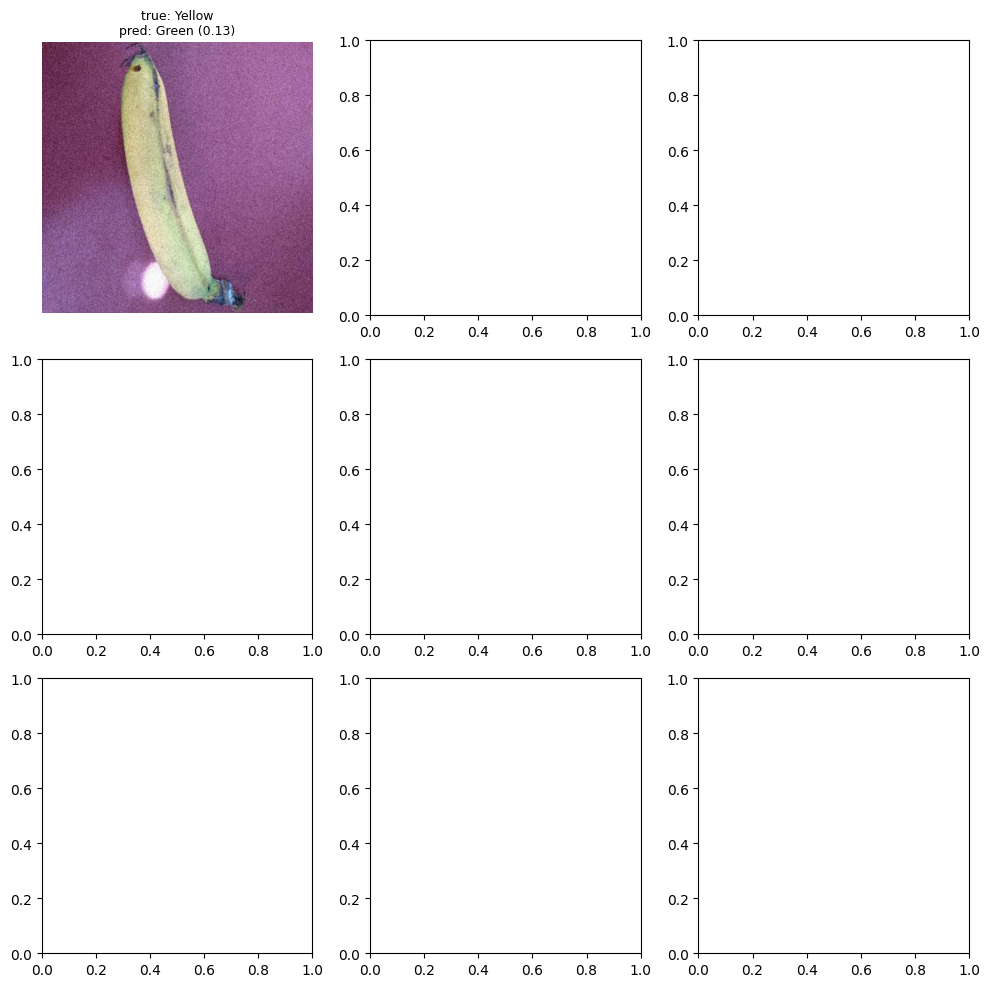

In [15]:
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(y_true)}")

n_show = min(9, len(wrong_idx))
if n_show > 0:
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for ax, idx in zip(axes.ravel(), wrong_idx[:n_show]):
        path = test_df.iloc[idx]["path"]
        true_label = DISPLAY_LABEL[test_df.iloc[idx]["label"]]
        pred_label = DISPLAY_LABEL["ripe" if y_pred[idx] == 1 else "unripe"]
        with Image.open(path) as im:
            ax.imshow(im)
        ax.set_title(f"true: {true_label}\npred: {pred_label} ({y_prob[idx]:.2f})", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Step 9 — Grad-CAM Sanity Check

Prove the model is actually attending to the banana, not to background artifacts or a lucky correlation with something incidental (e.g. a colored background/tray that happens to correlate with one class in this dataset). If the heatmaps consistently light up outside the banana, the model learned a shortcut and the accuracy number is not trustworthy regardless of what Step 7 says.

In [16]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name="Conv_1"):
    grad_model = tf.keras.models.Model(
        model.inputs, [base_model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model([img_array])   # <-- wrapped in a list here
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()
sample_paths = test_df.sample(min(6, len(test_df)), random_state=SEED)["path"].values
fig, axes = plt.subplots(2, 3, figsize=(50,60))   # bigger canvas
for ax, path in zip(axes.ravel(), sample_paths):
    with Image.open(path) as im:
        im = im.convert("RGB").resize(IMG_SIZE)
        arr = np.asarray(im).astype("float32")
    inp = tf.keras.applications.mobilenet_v2.preprocess_input(arr.copy())[np.newaxis, ...]
    try:
        heatmap = make_gradcam_heatmap(inp, model, base)
        heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
        ax.imshow(arr.astype("uint8"))
        ax.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    except Exception as e:
        ax.imshow(arr.astype("uint8"))
        ax.set_title(f"Grad-CAM failed: {e}", fontsize=8)
    ax.axis("off")
plt.suptitle("Grad-CAM: where the model is looking")
plt.tight_layout()
plt.show()